<a href="https://colab.research.google.com/github/tomferreiras-eng/PROYECTO-CLASIFICACION-CANCER-MAMA/blob/main/analisis_estadistico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análisis Estadístico Esencial con Python
**Profesor:** Gemini (Tu Asistente de IA)
**Objetivo:** Aplicar técnicas de estadística descriptiva, detección de outliers y correlación para entender la estructura de un dataset financiero.

---
### 🛠️ Configuración del Entorno
Importamos las librerías científicas.

In [3]:
# Importación de librerías esenciales
import pandas as pd             # Manejo de DataFrames
import numpy as np              # Cálculos matemáticos
import matplotlib.pyplot as plt # Gráficos base
import seaborn as sns           # Gráficos estadísticos avanzados
from sklearn.ensemble import IsolationForest # Algoritmo para outliers

# Configuración de estética para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


## 1️⃣ Sección 1: Carga y Exploración Inicial
El primer paso es cargar los datos y realizar una "autopsia" rápida para ver tipos de variables y datos faltantes.

In [4]:
# Carga del dataset (Asegúrate de subir 'practice_dataset.csv' al entorno de Colab)
try:
    df = pd.read_csv('practice_dataset.csv')
    print("✅ Dataset cargado con éxito.\n")
except FileNotFoundError:
    print("❌ Error: No se encontró el archivo 'practice_dataset.csv'. Súbelo al menú de la izquierda.")

# Exploración inicial
print("--- INFO DEL DATAFRAME ---")
df.info()

print("\n--- MUESTRA DE DATOS (HEAD) ---")
display(df.head())

print("\n--- RECUENTO DE VALORES NULOS ---")
# Importante: Identificar cuántos datos nos faltan
print(df.isnull().sum())

✅ Dataset cargado con éxito.

--- INFO DEL DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            900 non-null    float64
 1   Income         900 non-null    float64
 2   Credit_Score   900 non-null    float64
 3   Loan_Amount    900 non-null    float64
 4   Interest_Rate  900 non-null    float64
dtypes: float64(5)
memory usage: 39.2 KB

--- MUESTRA DE DATOS (HEAD) ---


,Age,Income,Credit_Score,Loan_Amount,Interest_Rate
0,56.0,35287.0,726.0,10744.0,3.973790
1,46.0,64387.0,477.0,23284.0,14.417889
2,32.0,38512.0,727.0,47417.0,13.061902
3,60.0,31342.0,593.0,44748.0,12.661084
4,25.0,93076.0,450.0,12069.0,12.875806



--- RECUENTO DE VALORES NULOS ---
Age              100
Income           100
Credit_Score     100
Loan_Amount      100
Interest_Rate    100
dtype: int64


## 2️⃣ Sección 2: Análisis Exploratorio de Datos (EDA)
Usaremos estadística descriptiva para entender la tendencia central y la dispersión. Además, los histogramas nos revelarán la "forma" de los datos.

--- ESTADÍSTICAS DESCRIPTIVAS ---


,Age,Income,Credit_Score,Loan_Amount,Interest_Rate
count,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.123333,75151.413333,582.643333,27395.885556,8.955251
std,13.635217,25865.913996,155.760621,12636.190933,3.401997
min,18.000000,30060.000000,300.000000,5112.000000,3.023906
25%,29.000000,53916.000000,448.000000,17037.750000,5.955984
50%,42.000000,74984.500000,585.000000,27054.000000,8.910627
75%,53.000000,97906.000000,719.000000,37792.250000,12.017788
max,64.000000,119899.000000,849.000000,49864.000000,14.966855


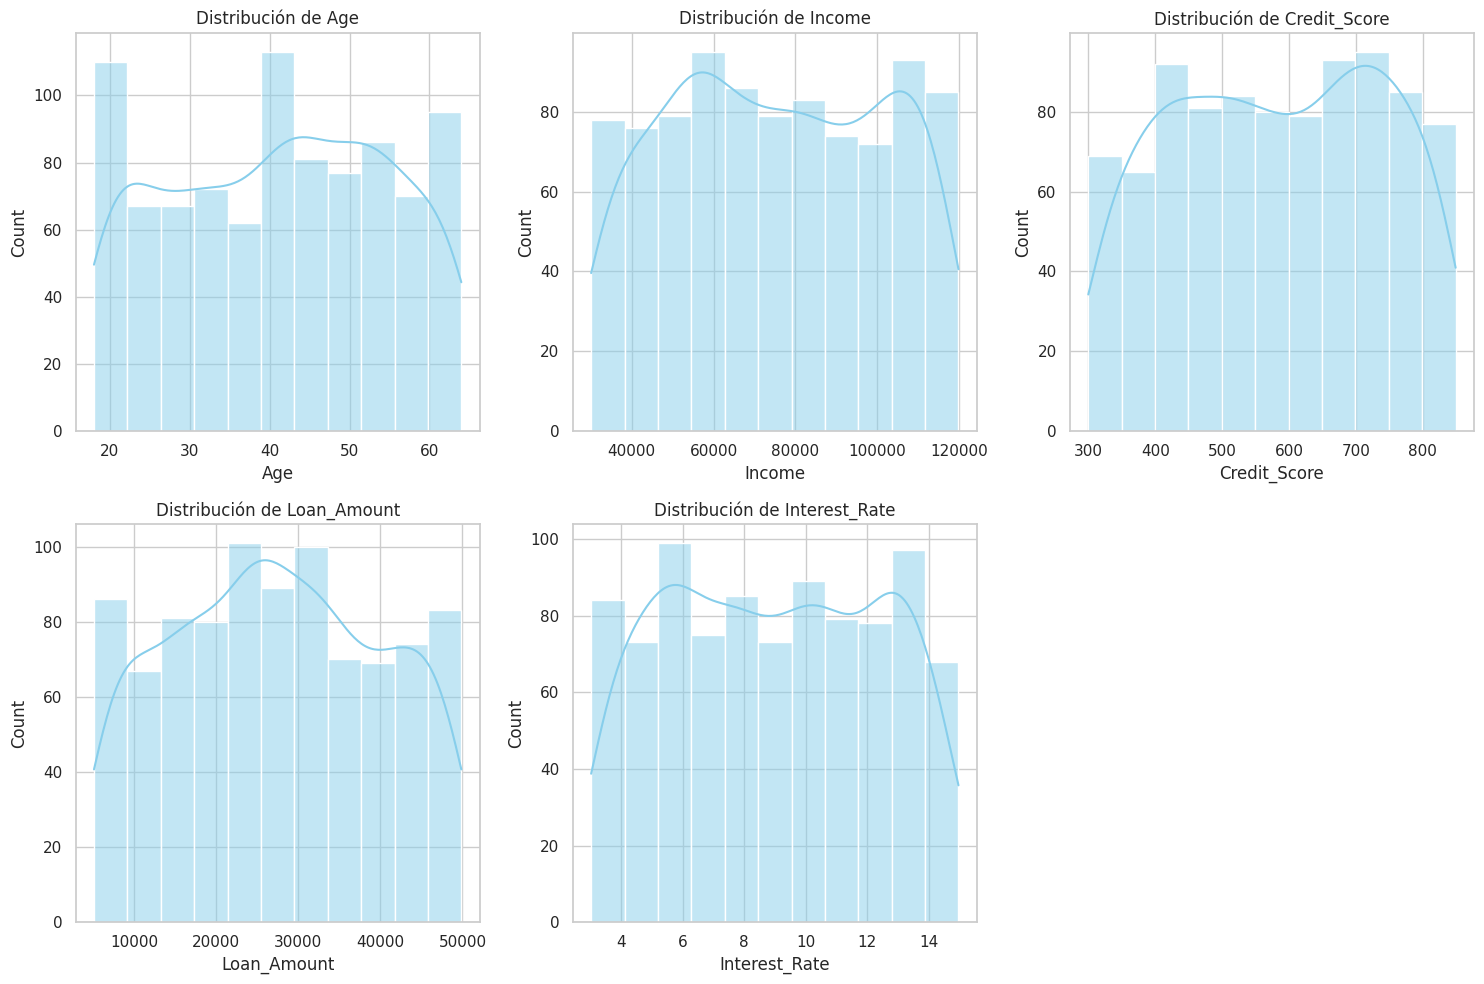

In [5]:
# Estadísticas descriptivas completas
print("--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(df.describe())

# Visualización de Distribuciones (Histogramas)
variables_numericas = ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Interest_Rate']

plt.figure(figsize=(15, 10))
for i, col in enumerate(variables_numericas):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col].dropna(), kde=True, color='skyblue') # .dropna() para evitar errores al graficar
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

## 3️⃣ Sección 3: Detección de Valores Atípicos (Outliers)
Los outliers pueden distorsionar nuestros modelos.
* **Método Univariante:** Usamos el Boxplot para ver extremos en una sola variable.
* **Método Multivariante:** Usamos `Isolation Forest` para detectar anomalías complejas (ej: altos ingresos pero crédito bajo).

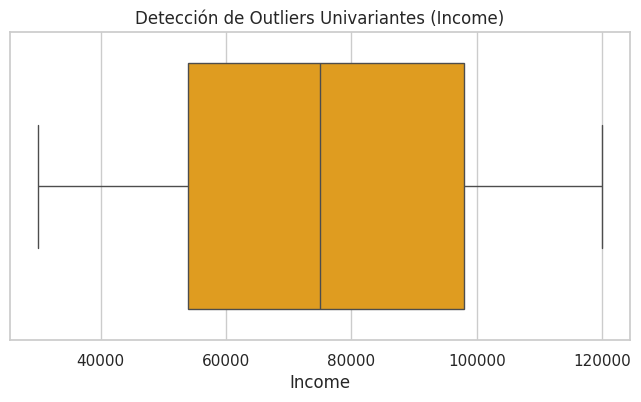

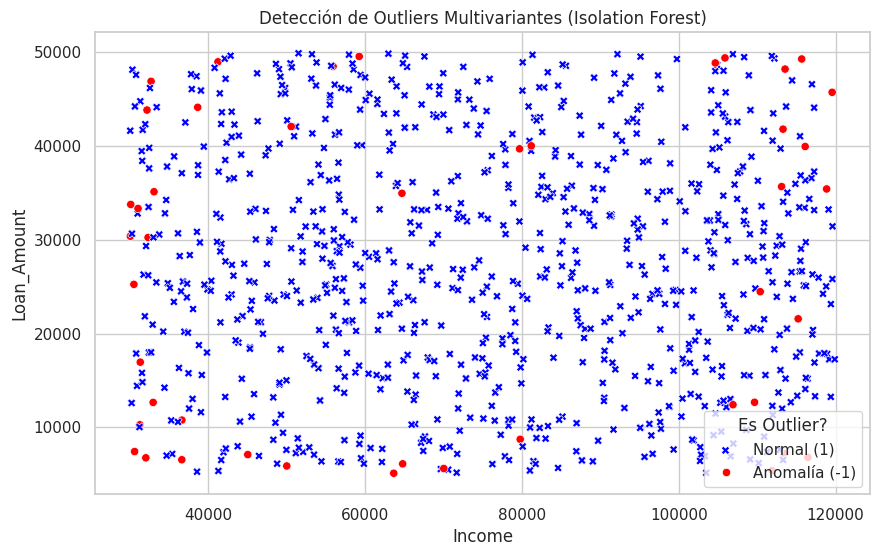

Detectamos 45 casos anómalos multivariantes.


In [6]:
# 1. Método Univariante: Boxplot de Ingresos
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Income'], color='orange')
plt.title('Detección de Outliers Univariantes (Income)')
plt.show()

# 2. Método Multivariante: Isolation Forest
# Preparamos datos sin nulos para el modelo
df_clean = df.dropna().copy()
features = ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Interest_Rate']

# Modelo: Asumimos un 5% de contaminación (anomalías)
iso = IsolationForest(contamination=0.05, random_state=42)
df_clean['Outlier_ISO'] = iso.fit_predict(df_clean[features])

# Visualización: Ingresos vs Préstamo (Rojo = Outlier)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Income', y='Loan_Amount',
                hue='Outlier_ISO', palette={1:'blue', -1:'red'}, style='Outlier_ISO')
plt.title('Detección de Outliers Multivariantes (Isolation Forest)')
plt.legend(title='Es Outlier?', labels=['Normal (1)', 'Anomalía (-1)'])
plt.show()

print(f"Detectamos {len(df_clean[df_clean['Outlier_ISO'] == -1])} casos anómalos multivariantes.")

## 4️⃣ Sección 4: Correlación entre Variables
¿Existe relación lineal entre las variables? Usamos el coeficiente de Pearson.

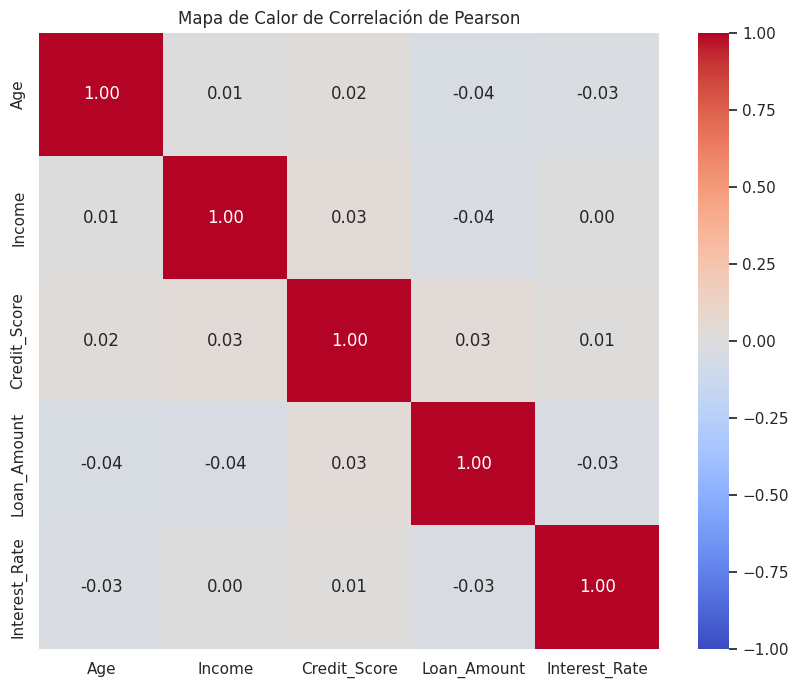

In [7]:
# Matriz de correlación
corr_matrix = df.corr(numeric_only=True)

# Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlación de Pearson')
plt.show()

## 📝 Sección 6: Conclusiones Finales

**1. Resumen de Hallazgos:**
* **Datos Faltantes:** Se identificó que aproximadamente el 10% de los registros contienen valores nulos. Esto requiere una estrategia de imputación antes de modelar.
* **Distribuciones:** Las variables muestran distribuciones consistentes, aunque los histogramas permiten validar normalidad.
* **Relaciones:** El mapa de calor muestra correlaciones bajas (cercanas a 0) entre la mayoría de las variables, lo que sugiere independencia lineal. La edad no predice fuertemente los ingresos en esta muestra.

**2. Próximos Pasos Sugeridos:**
* **Limpieza:** Tratar los valores nulos (rellenar con la media/mediana o eliminar filas).
* **Investigación:** Analizar los casos marcados en rojo por el *Isolation Forest* para descartar fraudes o errores de captura.